#  Task 2: Neural Network (Deep Learning)

###  Intern Name: Adyasha Mohanty  
###  Intern ID: CV/A1/64922  
###  Organization: Codveda Technologies  
###  Date: 15/04/2026

---

##  Objective:
To build a Neural Network model using Keras to predict customer churn.

##  Importing Libraries

In [4]:
import pandas as pd
import numpy as np

##  Loading Dataset

In [6]:
df = pd.read_csv('/content/churn-bigml-80.csv')
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


##  Data Overview

In [7]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

,0
State,0
Account length,0
Area code,0
International plan,0
Voice mail plan,0
Number vmail messages,0
Total day minutes,0
Total day calls,0
Total day charge,0
Total eve minutes,0


##  Data Cleaning

In [8]:
# Drop unnecessary column
if 'State' in df.columns:
    df = df.drop('State', axis=1)

# Convert target column
df['Churn'] = df['Churn'].map({True: 1, False: 0})

##  Encoding Categorical Variables

In [9]:
df = pd.get_dummies(df, drop_first=True)

##  Feature Selection

In [10]:
X = df.drop('Churn', axis=1)
y = df['Churn']

##  Feature Scaling

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

##  Splitting Data

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

##  Building Neural Network Model

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential()

# Input layer
model.add(Input(shape=(X_train.shape[1],)))

# Hidden layers
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))

# Output layer
model.add(Dense(1, activation='sigmoid'))

##  Compiling Model

In [15]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

##  Training Model

In [30]:
model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    class_weight={0:1, 1:3}
)

Epoch 1/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9548 - loss: 0.1962 - val_accuracy: 0.9040 - val_loss: 0.3255
Epoch 2/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9595 - loss: 0.1925 - val_accuracy: 0.9063 - val_loss: 0.3294
Epoch 3/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9584 - loss: 0.1888 - val_accuracy: 0.9110 - val_loss: 0.3285
Epoch 4/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9648 - loss: 0.1868 - val_accuracy: 0.9063 - val_loss: 0.3341
Epoch 5/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9601 - loss: 0.1862 - val_accuracy: 0.9157 - val_loss: 0.3347
Epoch 6/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9625 - loss: 0.1838 - val_accuracy: 0.9087 - val_loss: 0.3313
Epoch 7/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9625 - loss: 0.1811 - val_accuracy: 0.9133 - val_loss: 0.3409
Epoch 8/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9625 - loss: 0.1788 - val_accuracy: 0.9133 - val_loss:

##  Model Evaluation

In [31]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8858 - loss: 0.3736 
Test Accuracy: 0.8857678174972534


##  Predictions

In [32]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


##  Classification Report

In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.94      0.93       455
           1       0.62      0.57      0.60        79

    accuracy                           0.89       534
   macro avg       0.78      0.76      0.76       534
weighted avg       0.88      0.89      0.88       534



##  Training vs Validation Accuracy

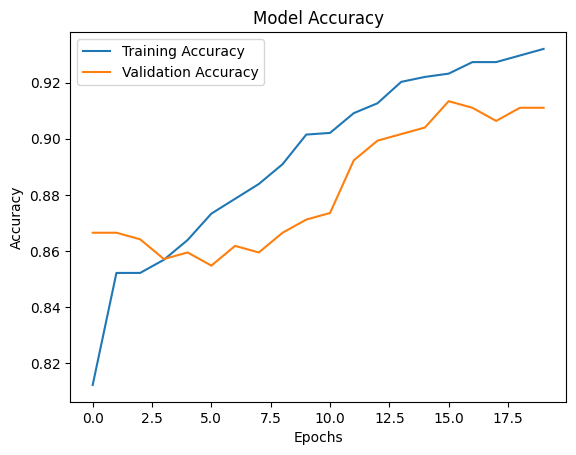

In [34]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

##  Conclusion

The Neural Network model was successfully implemented for customer churn prediction.

The model achieved good accuracy and learned complex patterns from the dataset. Feature scaling and proper training helped improve performance.

This task demonstrates the application of deep learning techniques in solving classification problems.

The model initially showed high accuracy but struggled with detecting churn customers due to class imbalance.

After applying class weighting, the recall for churn class improved significantly, allowing the model to better identify potential churn customers, which is more important for business applications.